# Analyse du DataSet supervise

In [1]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
try:
    df = pd.read_csv("../../kidneyData.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

print(df)

       Unnamed: 0       image_id  \
0               0  Tumor- (1044)   
1               1    Tumor- (83)   
2               2   Tumor- (580)   
3               3  Tumor- (1701)   
4               4  Tumor- (1220)   
...           ...            ...   
12441       12441   Cyst- (2522)   
12442       12442   Cyst- (2627)   
12443       12443    Cyst- (972)   
12444       12444   Cyst- (2323)   
12445       12445   Cyst- (2145)   

                                                    path   diag  target  Class  
0      /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
1      /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
2      /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
3      /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
4      /content/data/CT KIDNEY DATASET Normal, CYST, ...  Tumor       3  Tumor  
...                                                  ...    ...     ...    ...  


## Verification contenu

### On va verifier si les column ont bien les bonnes valeurs

In [3]:
Class_Verif = df['Class'].isin(['Tumor', 'Cyst', 'Normal', "Stone"]).all()
print("La column Class ne contient que nos 4 types:", Class_Verif)

Diag_Verif = df['diag'].isin(['Tumor', 'Cyst', 'Normal', "Stone"]).all()
print("La column Diag ne contient que nos 4 types:", Diag_Verif, "\n")


print("Verification des types du dataset:")
print(df.dtypes, "\n")

print("Presence de valeur NaN dans le dataset:", df.isnull().values.any())

La column Class ne contient que nos 4 types: True
La column Diag ne contient que nos 4 types: True 

Verification des types du dataset:
Unnamed: 0    int64
image_id        str
path            str
diag            str
target        int64
Class           str
dtype: object 

Presence de valeur NaN dans le dataset: False


##### On voit donc que tout notre dataset est conforme au niveau du type et des attendues.
##### On va maintenant verifier la conformite des images.

### On va verifier la taille des images du dataset pour voir si elles sont toute egales

In [4]:
chemin_image = '../../CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/Tumor- (83).jpg'
image = plt.imread(chemin_image)
plt.imshow(image)
plt.axis('off')
plt.show()


chemin_image = '../../CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/Tumor- (2281).jpg'
image = plt.imread(chemin_image)

plt.imshow(image)
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/Tumor- (83).jpg'

##### On observe donc que deux images ne sont pas de la meme taille, on va donc devoir normnaliser les images.
##### Mais avant ca, on remarque que les liens du csv donc dans noytre dataframe n'ont pas le bon chemin, il faut supprimer `/content/data/` pour que ce soit identique a notre projet

In [ ]:
df['path'] = df['path'].str.replace('/content/data/', '')
print(df['path'])

0        CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
1        CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
2        CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
3        CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
4        CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
                               ...                        
12441    CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
12442    CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
12443    CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
12444    CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
12445    CT KIDNEY DATASET Normal, CYST, TUMOR and STON...
Name: path, Length: 12446, dtype: str


##### Analyse types d'images (RGB ou grise), cette verification est en realites inutile mais nous la laissons comme preuve

In [ ]:
# from collections import Counter
# def verifier_array_image(img_array):
#     if len(img_array.shape) == 2:
#         return "Grayscale"
#     elif len(img_array.shape) == 3:
#         return "RGB"
#     return "Inconnu"



# chemin_dossier = '../../CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/'
# taille_standard = (128, 128)

# types_couleur = []

# # boucle pour parcourir tout le dossier
# for nom_fichier in os.listdir(chemin_dossier):
#     # on combimne le chemin avec le nom du fichier pour avoir le bon link
#     chemin_complet = os.path.join(chemin_dossier, nom_fichier)
#     img = cv2.imread(chemin_complet, cv2.IMREAD_UNCHANGED)
#     if len(img.shape) == 2:
#         types_couleur.append("Grayscale")
#     elif len(img.shape) == 3:
#         types_couleur.append("RGB")
#     else:
#         types_couleur.append("Inconnu")


# Counter(types_couleur)

Counter({'RGB': 2283})

##### Maintenant nous allons redimensionner les images

In [ ]:
chemin_dossier = '../../CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/'
taille_standard = (128, 128)

images_traitees = []

# boucle pour parcourir tout le dossier
for nom_fichier in os.listdir(chemin_dossier):
    # on combimne le chemin avec le nom du fichier pour avoir le bon link
    chemin_complet = os.path.join(chemin_dossier, nom_fichier)
    
    # lecture de l'img
    img = cv2.imread(chemin_complet)
    
    # on passe en gris les images pour regler les problemes de rgb
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    #redimension
    img_resized = cv2.resize(gray, taille_standard)
    
    images_traitees.append(img_resized)


# On stocke tout nos array dans X_tumeurs
X_tumeurs = np.array(images_traitees)



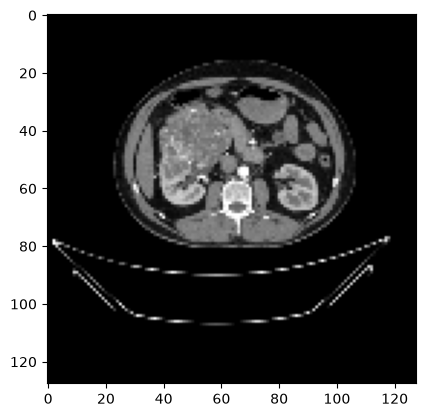

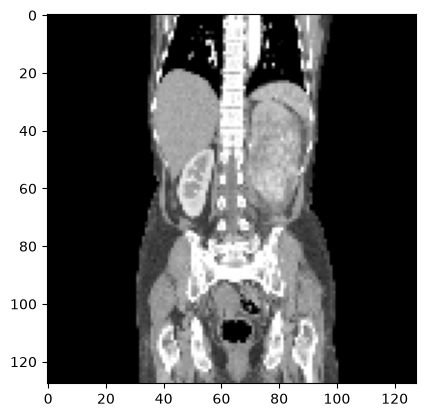

In [ ]:
plt.imshow(X_tumeurs[250], cmap='gray')
plt.axis('on')
plt.show()

plt.imshow(X_tumeurs[42], cmap='gray')
plt.axis('on')
plt.show()

raise SystemExit(0)

##### Nous avons donc maintenant les images d'un dossier entier redimensionner et stocker sous forme d'array pour l'utilisations des models.
##### Attention ici nous ne faisons pas de .flattend() car si nous l'utilisons, cela va transofrmer notre array et il sera impossible d'afficher l'image avec un graph.

### Analyse des column inutile

Dans le dataset finale nous n'avons pas besoin de tute les column actuel.

Les column que nous n'allons pas garder sont :
    - `path` --> Nous n'avons pas besoin de garder les chemins puisque nous allons directement stocker les matrice dans le dataset et si on veut les retrouver nous avons le `image_id`
    - `Class` --> Dans notre dataset les `Class` et `diag` sont identique pour toutes les lignes (informations issue du site inernet directement)

Le reste des column nous allons les garder car elles sont necessaire pour nos model. Nous ajouterons egalement d'autres column comme `matrice` qui contiendra l'array de chaque image.

#### Analyse array numpy
Nous allons devoir dans le preprocess 

## Ceci conclu notre PreAnalyse il va donc falloir realiser le PreProcessing (voir PreProcessing.ipynb)